In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8')
print("✅ Libraries loaded")

✅ Libraries loaded


In [5]:
nav_df  = pd.read_csv("data/processed/nav_history_cleaned.csv")
fund_df = pd.read_csv("data/processed/fund_master_cleaned.csv")

nav_df["date"] = pd.to_datetime(nav_df["date"])

print("NAV shape:", nav_df.shape)
print("Fund shape:", fund_df.shape)
nav_df.head()

NAV shape: (45962, 3)
Fund shape: (40, 15)


,amfi_code,date,nav
0,100016,2022-01-02,512.1124
1,100016,2022-01-03,503.1674
2,100016,2022-01-04,531.2850
3,100016,2022-01-06,474.1732
4,100016,2022-01-07,452.5840


In [6]:
print("=== NAV Statistics ===")
print(nav_df["nav"].describe())

print("\n=== Fund Categories ===")
print(fund_df["category"].value_counts())

print("\n=== Risk Categories ===")
print(fund_df["risk_category"].value_counts())

=== NAV Statistics ===
count    45962.000000
mean       269.730226
std        577.391885
min         26.136600
25%         69.228975
50%        122.821150
75%        260.550600
max       4268.549700
Name: nav, dtype: float64

=== Fund Categories ===
category
Equity    34
Debt       6
Name: count, dtype: int64

=== Risk Categories ===
risk_category
Moderate           16
High                8
Very High           6
Low                 6
Moderately High     4
Name: count, dtype: int64


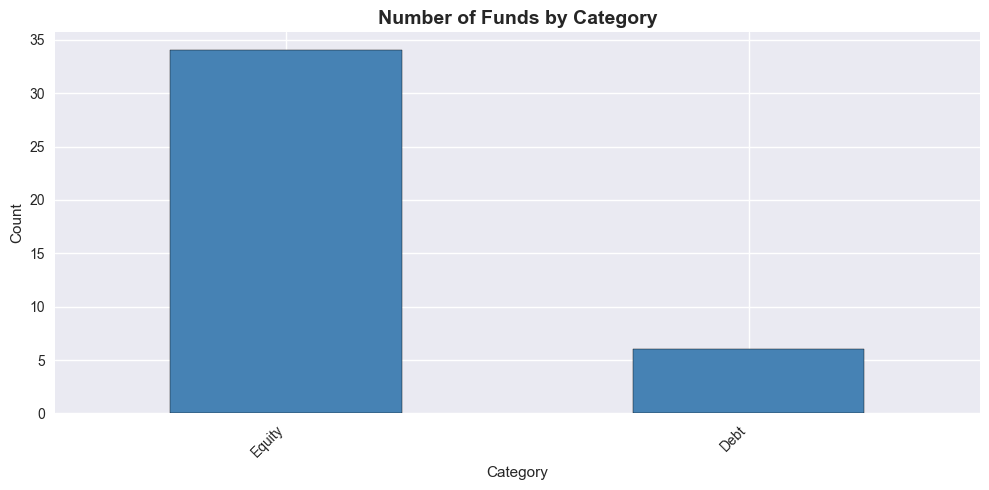

✅ Chart 1 saved


In [7]:
import os
os.makedirs("../reports", exist_ok=True)

plt.figure(figsize=(10, 5))
fund_df["category"].value_counts().plot(
    kind="bar", color="steelblue", edgecolor="black"
)
plt.title("Number of Funds by Category", fontsize=14, fontweight="bold")
plt.xlabel("Category")
plt.ylabel("Count")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig("../reports/chart1_funds_by_category.png", dpi=150)
plt.show()
print("✅ Chart 1 saved")

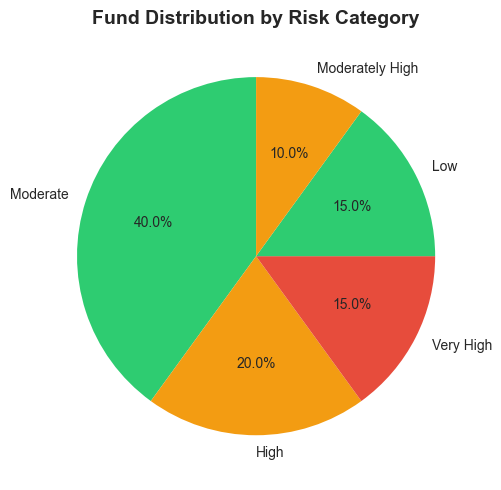

✅ Chart 2 saved


In [8]:
plt.figure(figsize=(7, 5))
colors = ["#2ecc71", "#f39c12", "#e74c3c"]
fund_df["risk_category"].value_counts().plot(
    kind="pie", autopct="%1.1f%%",
    colors=colors, startangle=90
)
plt.title("Fund Distribution by Risk Category",
          fontsize=14, fontweight="bold")
plt.ylabel("")
plt.tight_layout()
plt.savefig("../reports/chart2_funds_by_risk.png", dpi=150)
plt.show()
print("✅ Chart 2 saved")

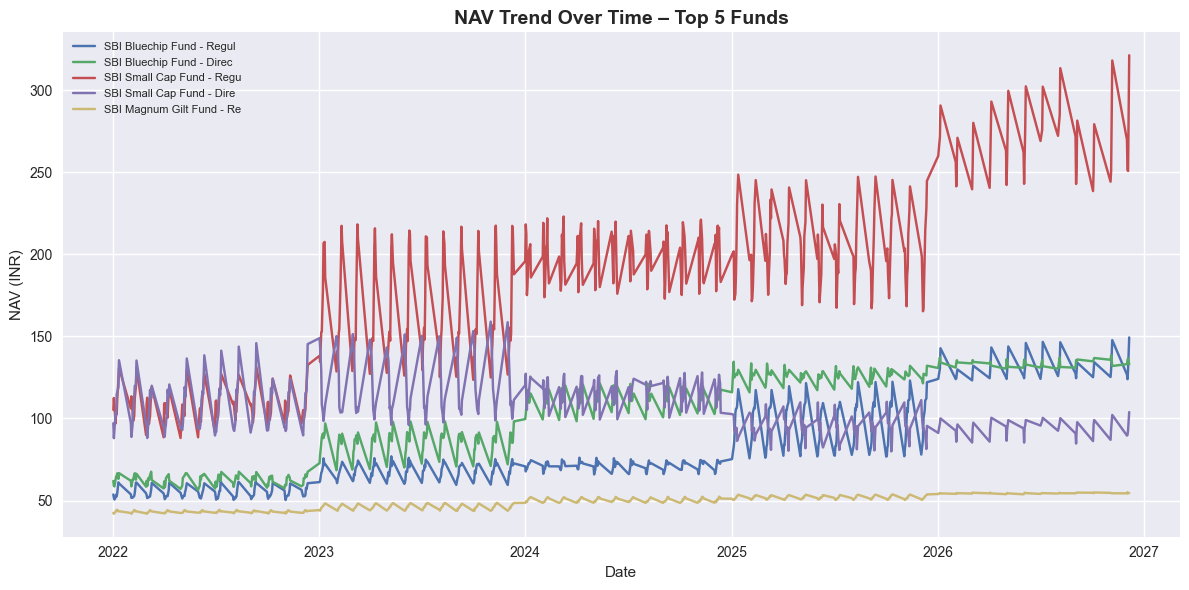

✅ Chart 3 saved


In [9]:
top_funds = fund_df.head(5)[["amfi_code", "scheme_name"]]

plt.figure(figsize=(12, 6))
for _, row in top_funds.iterrows():
    fund_nav = nav_df[
        nav_df["amfi_code"] == row["amfi_code"]
    ].sort_values("date")
    plt.plot(fund_nav["date"], fund_nav["nav"],
             label=row["scheme_name"][:25])

plt.title("NAV Trend Over Time – Top 5 Funds",
          fontsize=14, fontweight="bold")
plt.xlabel("Date")
plt.ylabel("NAV (INR)")
plt.legend(fontsize=8)
plt.tight_layout()
plt.savefig("../reports/chart3_nav_trend.png", dpi=150)
plt.show()
print("✅ Chart 3 saved")

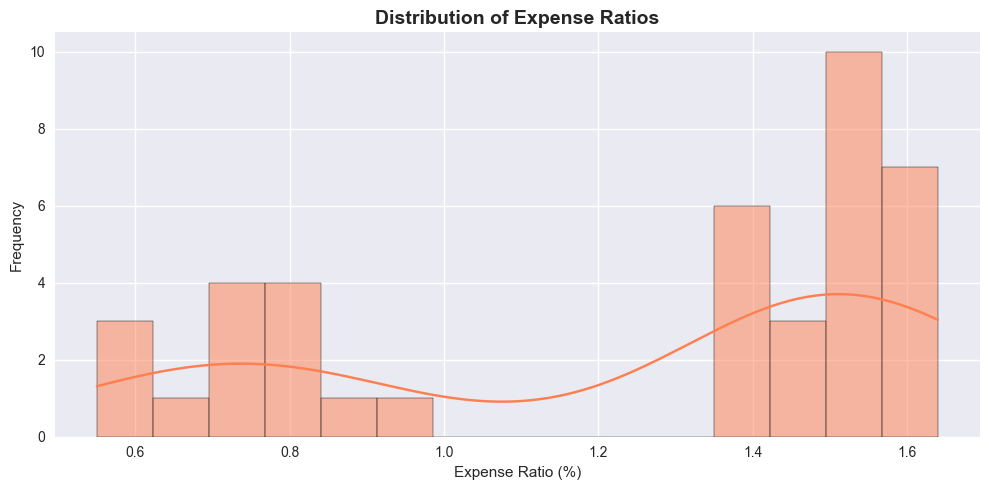

✅ Chart 4 saved


In [10]:
plt.figure(figsize=(10, 5))
sns.histplot(
    fund_df["expense_ratio_pct"].dropna(),
    bins=15, kde=True, color="coral"
)
plt.title("Distribution of Expense Ratios",
          fontsize=14, fontweight="bold")
plt.xlabel("Expense Ratio (%)")
plt.ylabel("Frequency")
plt.tight_layout()
plt.savefig("../reports/chart4_expense_ratio.png", dpi=150)
plt.show()
print("✅ Chart 4 saved")

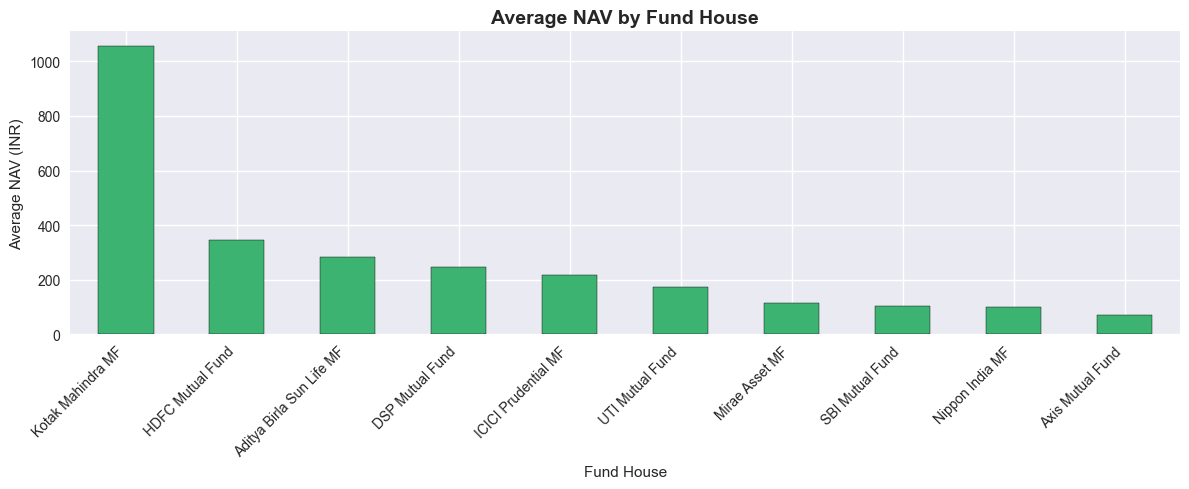

✅ Chart 5 saved


In [11]:
avg_nav = nav_df.merge(
    fund_df[["amfi_code", "fund_house"]], on="amfi_code"
)
avg_by_house = avg_nav.groupby("fund_house")["nav"].mean()\
                      .sort_values(ascending=False)

plt.figure(figsize=(12, 5))
avg_by_house.plot(
    kind="bar", color="mediumseagreen", edgecolor="black"
)
plt.title("Average NAV by Fund House",
          fontsize=14, fontweight="bold")
plt.xlabel("Fund House")
plt.ylabel("Average NAV (INR)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig("../reports/chart5_avg_nav_by_house.png", dpi=150)
plt.show()
print("✅ Chart 5 saved")

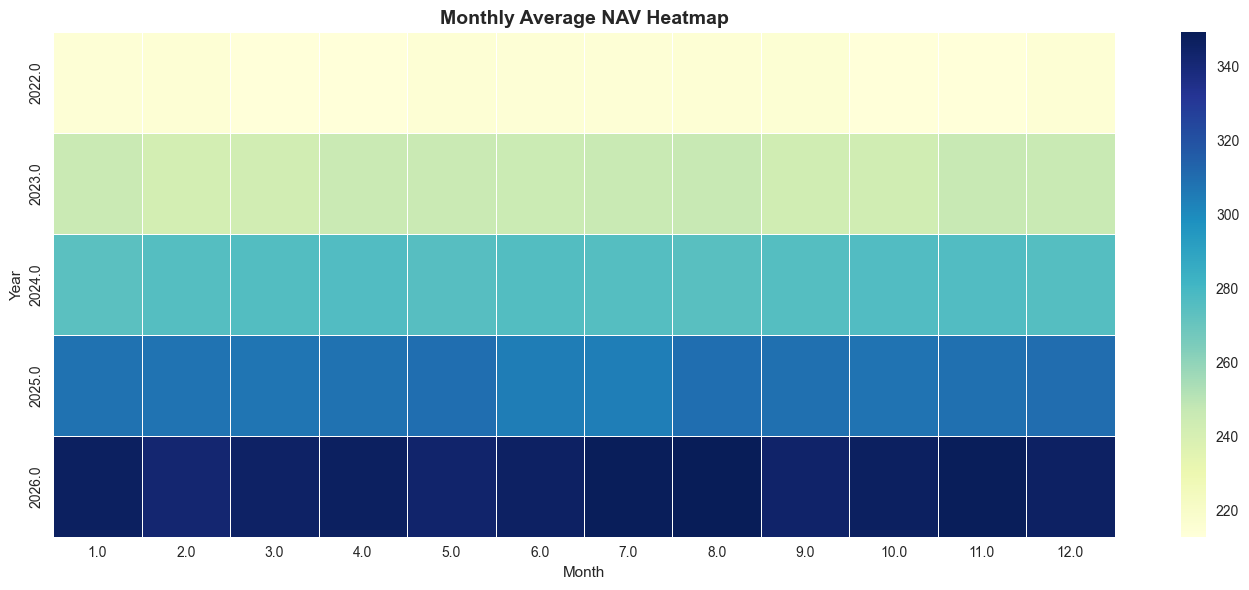

✅ Chart 6 saved


In [12]:
nav_df["month"] = nav_df["date"].dt.month
nav_df["year"]  = nav_df["date"].dt.year

monthly_avg = nav_df.groupby(
    ["year", "month"]
)["nav"].mean().unstack()

plt.figure(figsize=(14, 6))
sns.heatmap(
    monthly_avg, cmap="YlGnBu",
    linewidths=0.5, annot=False
)
plt.title("Monthly Average NAV Heatmap",
          fontsize=14, fontweight="bold")
plt.xlabel("Month")
plt.ylabel("Year")
plt.tight_layout()
plt.savefig("../reports/chart6_monthly_heatmap.png", dpi=150)
plt.show()
print("✅ Chart 6 saved")

In [13]:
print("""
=== KEY EDA INSIGHTS ===

1. Total funds analysed     : {}
2. Total NAV records        : {}
3. Date range               : {} to {}
4. Average NAV              : ₹{:.2f}
5. Highest NAV recorded     : ₹{:.2f}
6. Lowest NAV recorded      : ₹{:.2f}
7. Most common risk category: {}
8. Most common category     : {}
9. Average expense ratio    : {:.2f}%
10. Funds with expense < 1% : {}
""".format(
    len(fund_df),
    len(nav_df),
    nav_df["date"].min().date(),
    nav_df["date"].max().date(),
    nav_df["nav"].mean(),
    nav_df["nav"].max(),
    nav_df["nav"].min(),
    fund_df["risk_category"].mode()[0],
    fund_df["category"].mode()[0],
    fund_df["expense_ratio_pct"].mean(),
    len(fund_df[fund_df["expense_ratio_pct"] < 1.0])
))
print("✅ Day 3 EDA Complete!")


=== KEY EDA INSIGHTS ===

1. Total funds analysed     : 40
2. Total NAV records        : 45962
3. Date range               : 2022-01-02 to 2026-12-05
4. Average NAV              : ₹269.73
5. Highest NAV recorded     : ₹4268.55
6. Lowest NAV recorded      : ₹26.14
7. Most common risk category: Moderate
8. Most common category     : Equity
9. Average expense ratio    : 1.24%
10. Funds with expense < 1% : 14

✅ Day 3 EDA Complete!
